# Patient inclusion and debiasing (experiment-on-existing-models papers)

This notebook plots pie summaries **restricted to papers whose `Paper Type` includes *Experiment on Existing Models***.

There was **no existing notebook cell** in this repo building these pies—related CSV columns appear only in dataframe previews elsewhere.

**Patient Inclusion**: any value starting with `Yes` is grouped as Yes.

Colors use Seaborn styling (`sns.set_theme`) with explicit green (#2ca02c) for **Yes** and red (#d62728) for **No**.

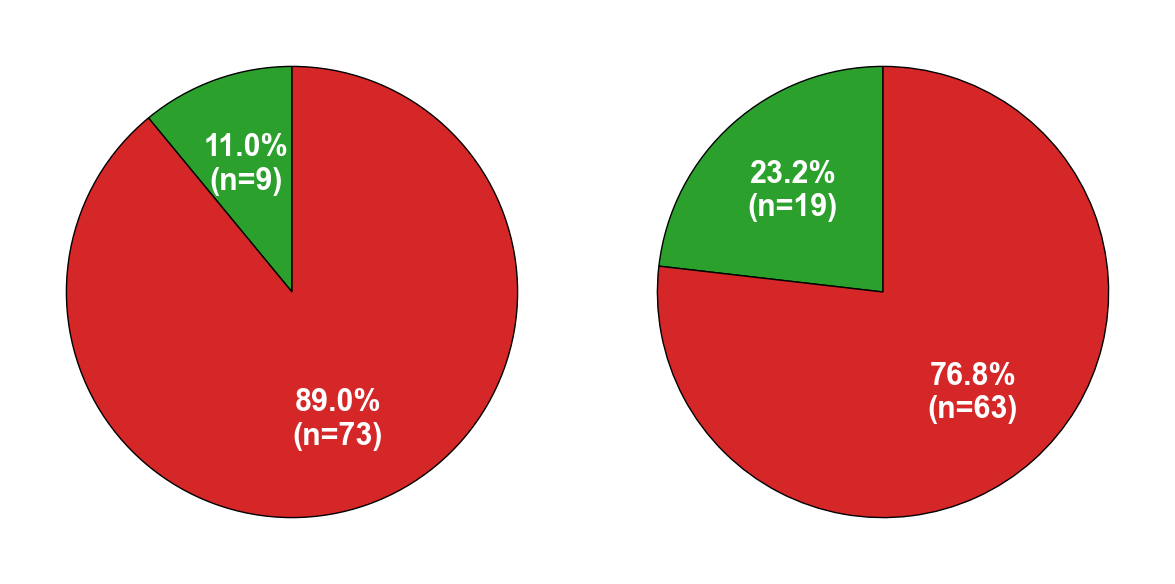

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

DATA_PATH = Path("../data/papers.csv")

sns.set_theme(style="white")

GREEN = "#2ca02c"
RED = "#d62728"
YES_NO_COLORS = {"Yes": GREEN, "No": RED}


def is_experiment_on_existing_models(value: object) -> bool:
    if not isinstance(value, str):
        return False
    return "experiment on existing models" in value.lower()


def patient_inclusion_bucket(value: object) -> str:
    if isinstance(value, str) and value.strip().lower().startswith("yes"):
        return "Yes"
    return "No"


def normalize_yes_no(value: object) -> str:
    if isinstance(value, str) and value.strip().lower() == "yes":
        return "Yes"
    return "No"


df = pd.read_csv(DATA_PATH)
exp_mask = df["Paper Type"].apply(is_experiment_on_existing_models)
sub = df.loc[exp_mask].copy()

sub["patient_inc"] = sub["Patient Inclusion"].apply(patient_inclusion_bucket)
sub["has_debias"] = sub["Has Debiasing"].apply(normalize_yes_no)

patient_counts = sub["patient_inc"].value_counts().reindex(["Yes", "No"]).fillna(0).astype(int)
debias_counts = sub["has_debias"].value_counts().reindex(["Yes", "No"]).fillna(0).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

series_list = [patient_counts, debias_counts]

for ax, counts in zip(axes, series_list):
    labels = counts.index.tolist()
    sizes = counts.values
    colors = [YES_NO_COLORS[l] for l in labels]
    wedges, _texts, autotexts = ax.pie(
        sizes,
        labels=None,
        autopct=lambda pct: f"{pct:.1f}%\n(n={int(round(pct / 100 * sizes.sum()))})",
        colors=colors,
        wedgeprops=dict(edgecolor="black", linewidth=1.0),
        startangle=90,
    )
    for t in autotexts:
        t.set_fontsize(22)
        t.set_fontweight("bold")
        t.set_color("white")

plt.tight_layout()
plt.show()